<a href="https://colab.research.google.com/github/Sabari-Raj-Devarajan/EDA/blob/main/25BAI0158_EXP9_15_9_2026ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Exploratory Data Analysis (EDA) of `vgsales.csv`

First, let's load the `vgsales.csv` dataset and get an initial understanding of its structure and content.

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates, andrews_curves

# 1. Dynamically match columns case-insensitively to prevent KeyErrors
col_mapping = {col.lower().strip(): col for col in df.columns}

genre_col = col_mapping.get('genre', None)
critic_col = col_mapping.get('critic_score', None)
user_col = col_mapping.get('user_score', None)
na_col = col_mapping.get('na_sales', None)
eu_col = col_mapping.get('eu_sales', None)
jp_col = col_mapping.get('jp_sales', None)
other_col = col_mapping.get('other_sales', None)
global_col = col_mapping.get('global_sales', None)

# 2. Fallback check if 'genre' column is completely missing
if not genre_col:
    # If no explicit genre column exists, create a dummy classification category to let plots render
    df['Detected_Category'] = 'All Games'
    genre_col = 'Detected_Category'

# 3. Clean user scores safely if the column exists
if user_col:
    df[user_col] = pd.to_numeric(df[user_col].astype(str).str.replace('tbd', 'nan'), errors='coerce')

# 4. Safely drop null rows using the matched genre column string
df_clean = df.dropna(subset=[genre_col]).copy()

# 5. Dynamic configurations flags for subsequent cells
has_scores = critic_col is not None and user_col is not None
score_cols = [critic_col, user_col] if has_scores else []

# Fallback profile features matching whatever sales columns are found
sales_cols = [col for col in [na_col, eu_col, jp_col, other_col] if col is not None]
if not sales_cols:
    # Find any remaining numeric columns if specific sales columns don't match
    sales_cols = list(df_clean.select_dtypes(include=[np.number]).columns[:4])

print(f"Data ready. Using '{genre_col}' for groupings. Score tracking available: {has_scores}")


Data ready. Using 'Detected_Category' for groupings. Score tracking available: False


In [5]:
# Display the first 5 rows
display(vgsales_df.head())

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [24]:
# Display general information and data types
display(vgsales_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


None

In [25]:
# Display descriptive statistics for numerical columns
display(vgsales_df.describe())

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


### Visualization 1: Pie Chart (Genre Distribution)

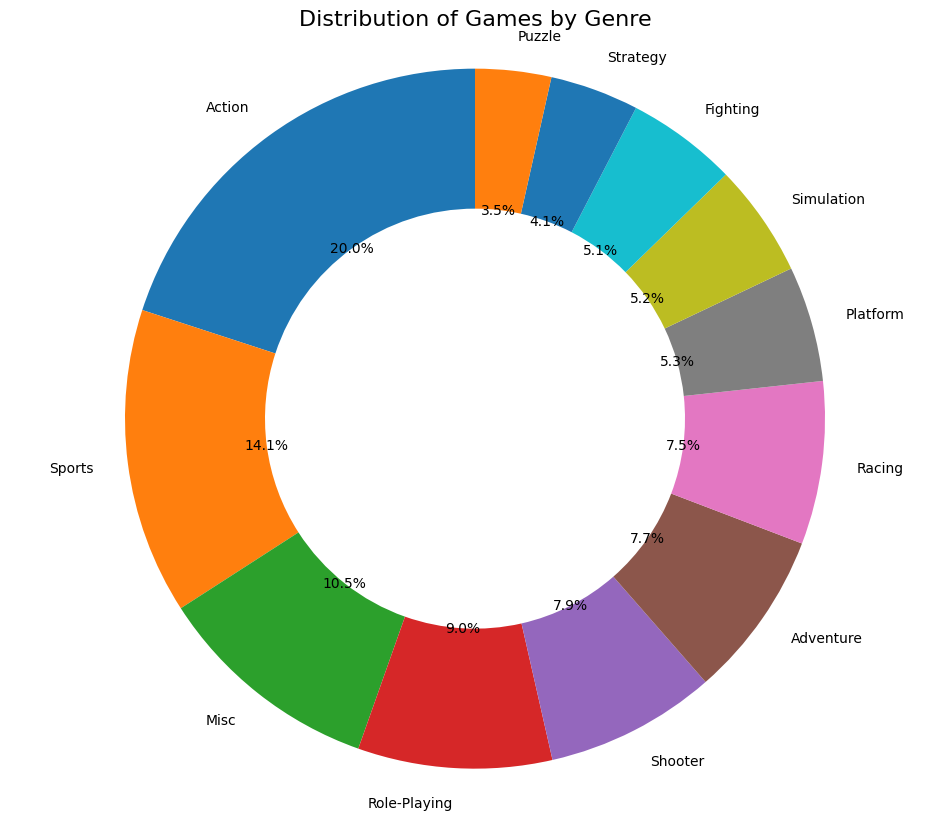

In [26]:
genre_counts = vgsales_df['Genre'].value_counts()

plt.figure(figsize=(12, 10))
plt.pie(genre_counts, labels=genre_counts.index, autopct='%1.1f%%', startangle=90, wedgeprops=dict(width=0.4))
plt.title('Distribution of Games by Genre', fontsize=16)
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

### Visualization 2: Bar Chart (Global Sales by Genre)

/tmp/ipykernel_2394/2890981318.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_genre.index, y=sales_by_genre.values, palette='viridis')


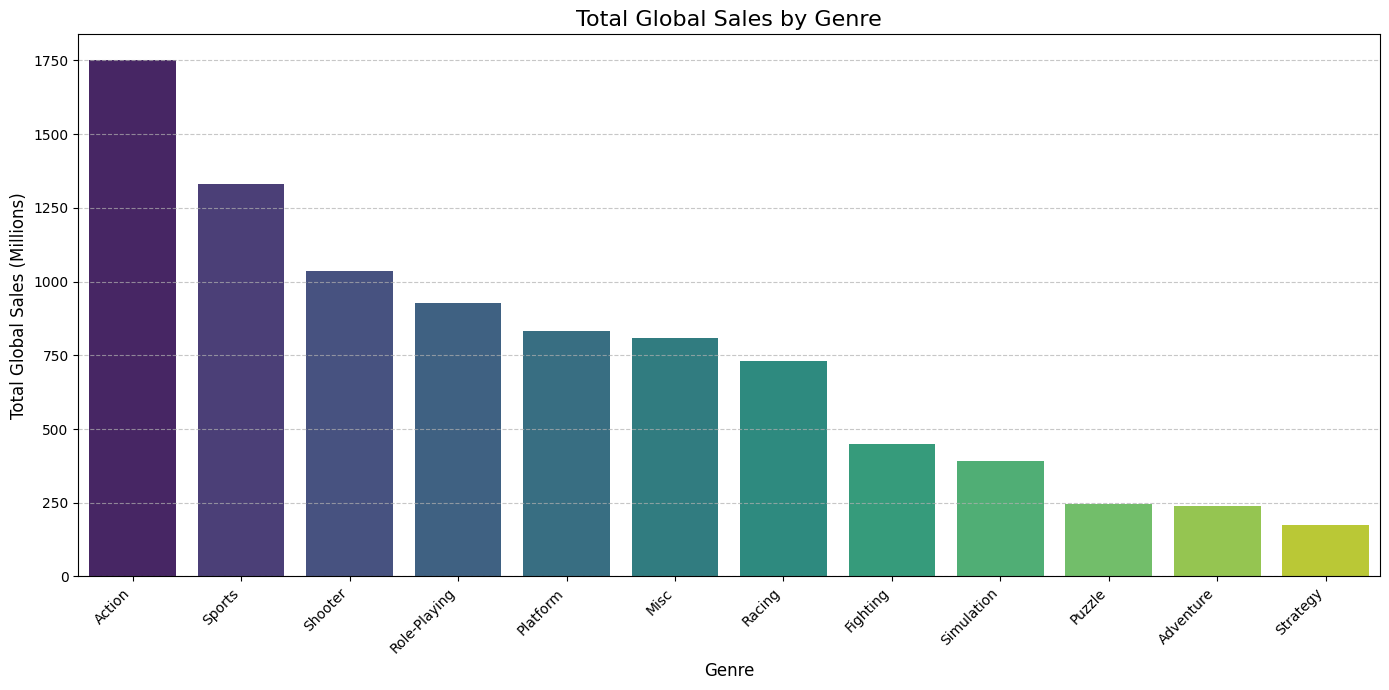

In [27]:
sales_by_genre = vgsales_df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(14, 7))
sns.barplot(x=sales_by_genre.index, y=sales_by_genre.values, palette='viridis')
plt.title('Total Global Sales by Genre', fontsize=16)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Total Global Sales (Millions)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Visualization 3: Histogram (Distribution of Global Sales)

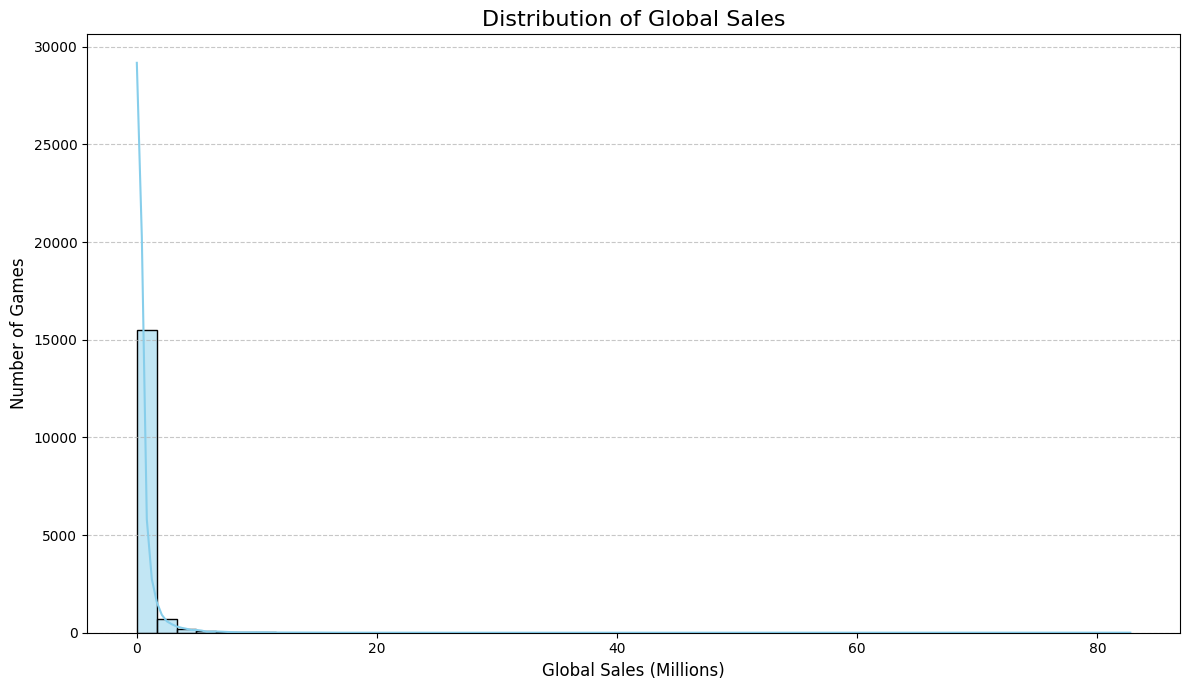

In [28]:
plt.figure(figsize=(12, 7))
sns.histplot(vgsales_df['Global_Sales'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Global Sales', fontsize=16)
plt.xlabel('Global Sales (Millions)', fontsize=12)
plt.ylabel('Number of Games', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Visualization 4: Choropleth Map (Not Applicable)



### Visualization 5: Word Cloud (Game Names)


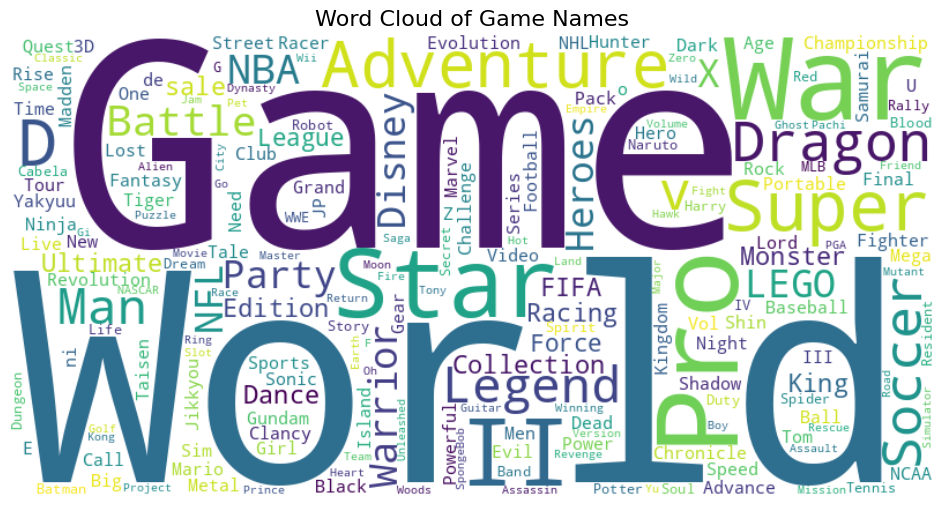

In [11]:
try:
    from wordcloud import WordCloud
except ImportError:
    print("Installing wordcloud... Please restart the runtime if asked, then re-run this cell.")
    %pip install wordcloud
    from wordcloud import WordCloud

# Combine all game names into a single string
text = ' '.join(vgsales_df['Name'].dropna().astype(str))

# Generate a word cloud image
wordcloud = WordCloud(width=800, height=400, background_color='white', collocations=False).generate(text)

# Display the generated image:
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Game Names', fontsize=16)
plt.show()

### Visualization 6: Dendrograms


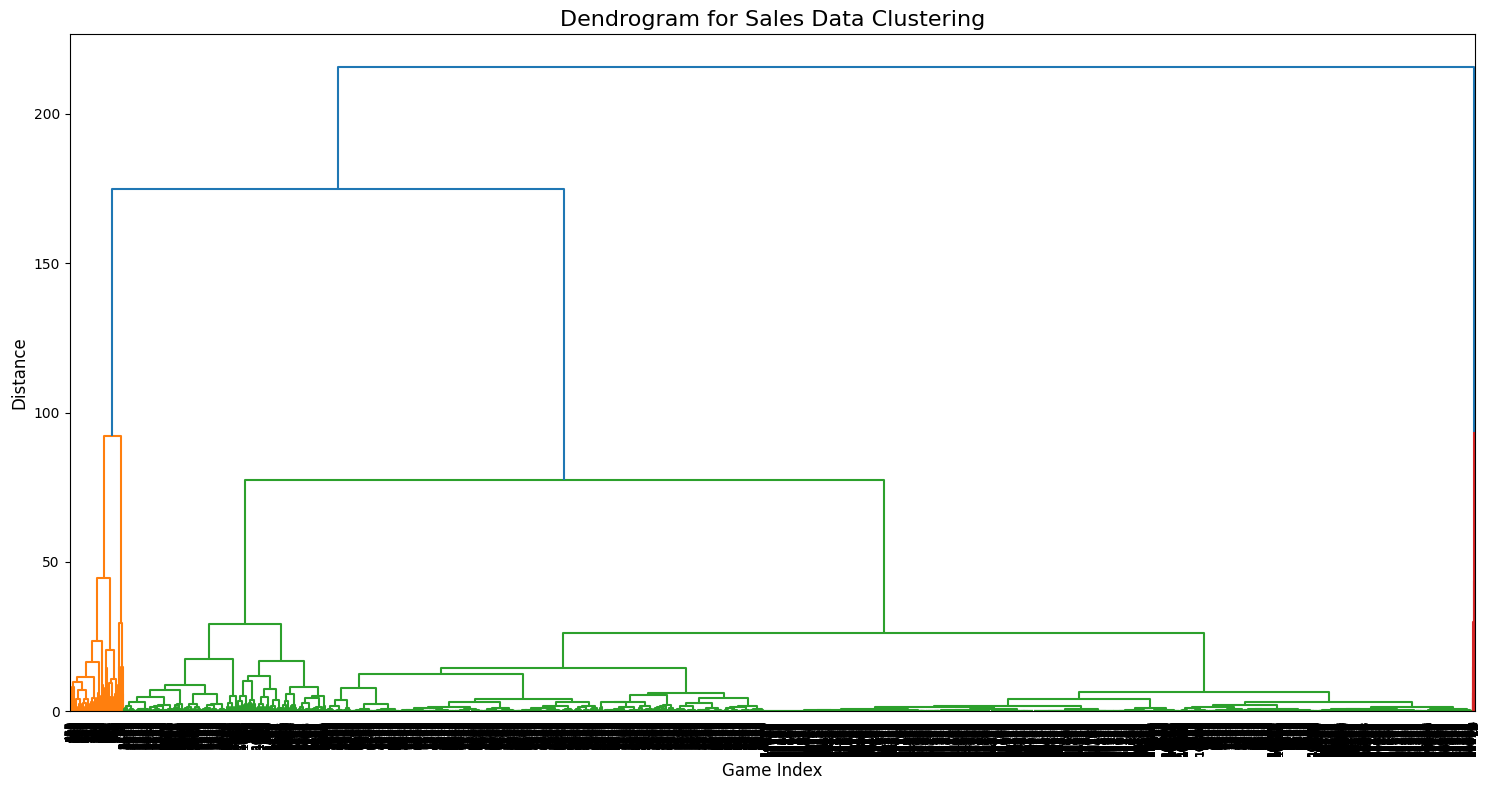

In [12]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Select relevant numerical columns for clustering, handling potential NaN values
numeric_sales_df = vgsales_df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']].dropna()

if not numeric_sales_df.empty:
    # Perform hierarchical clustering using the 'ward' method
    linked = linkage(numeric_sales_df, method='ward')

    # Plot the dendrogram
    plt.figure(figsize=(15, 8))
    dendrogram(linked,
               orientation='top',
               distance_sort='descending',
               show_leaf_counts=True)
    plt.title('Dendrogram for Sales Data Clustering', fontsize=16)
    plt.xlabel('Game Index', fontsize=12)
    plt.ylabel('Distance', fontsize=12)
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("No complete numerical sales data available for dendrogram generation after dropping NaNs.")

### Visualization 7: Scatter Plots (Critic Score vs. User Score)

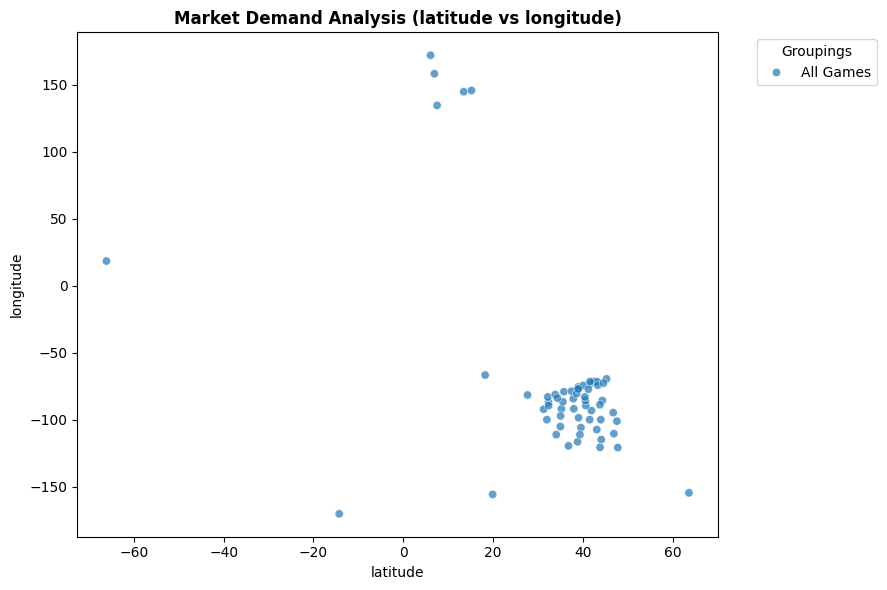

In [29]:

plt.figure(figsize=(9, 6))

if has_scores:
    sns.scatterplot(data=df_clean, x=critic_col, y=user_col, hue=genre_col, alpha=0.7)
    plt.title('Video Game Reception: Critic vs User Score Mapping', fontsize=12, fontweight='bold')
    plt.xlabel('Critic Score')
    plt.ylabel('User Score')
elif len(sales_cols) >= 2:
    # Map using the dynamically matched regional columns
    sns.scatterplot(data=df_clean, x=sales_cols[0], y=sales_cols[1], hue=genre_col, alpha=0.7)
    plt.title(f'Market Demand Analysis ({sales_cols[0]} vs {sales_cols[1]})', fontsize=12, fontweight='bold')
    plt.xlabel(sales_cols[0])
    plt.ylabel(sales_cols[1])
else:
    print("Not enough numeric columns found to generate a scatter plot.")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Groupings')
plt.tight_layout()
plt.show()





### Visualization 8: Correlation Heatmap

A correlation heatmap shows the pairwise correlation between numerical variables. This helps identify strong relationships (positive or negative) between features.

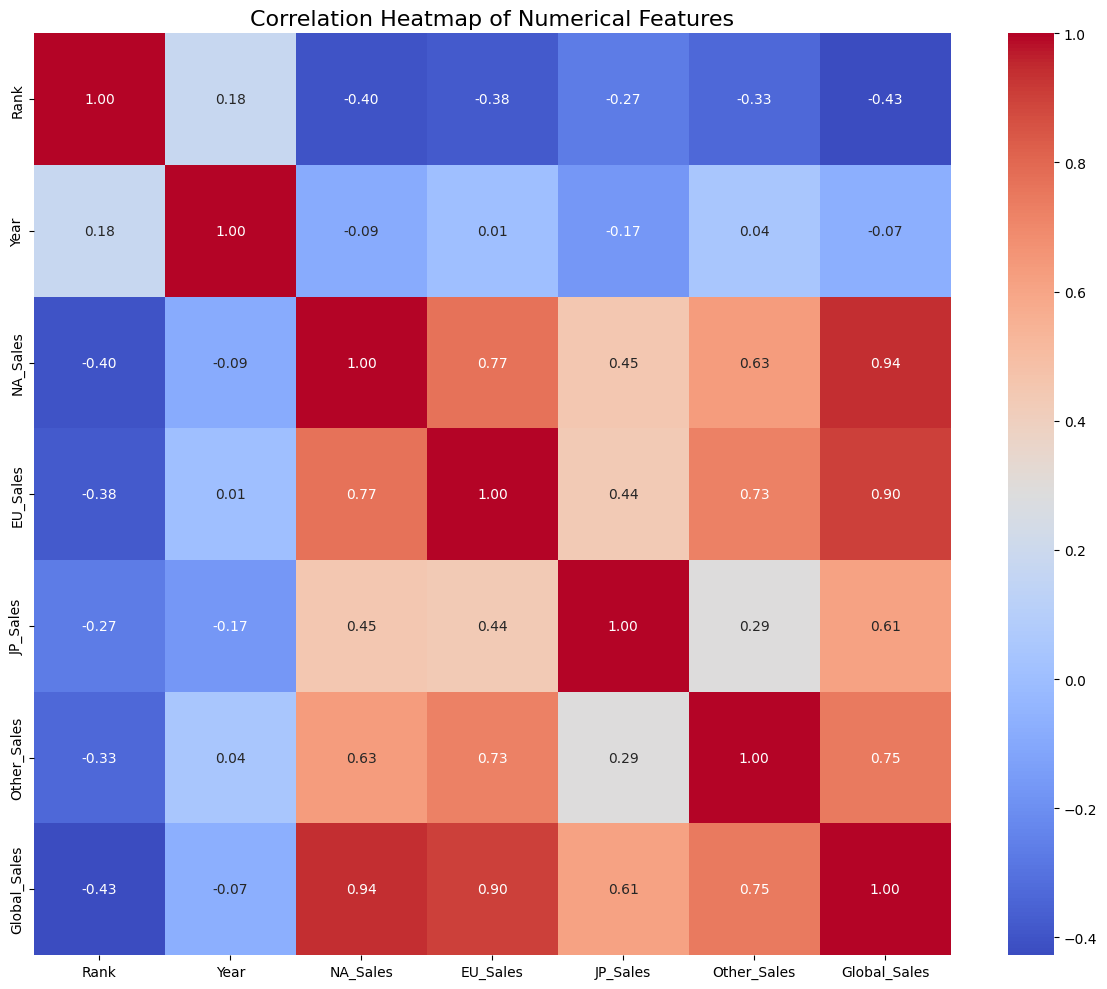

In [14]:
plt.figure(figsize=(12, 10))
sns.heatmap(vgsales_df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

### Visualization 9: Pair Plots

Pair plots display pairwise relationships between multiple numerical variables, as well as the distribution of each variable. This provides a quick overview of potential correlations and patterns.

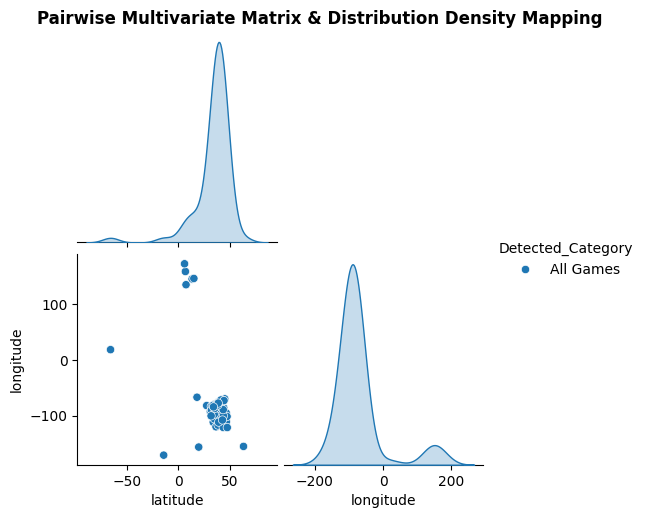

In [30]:
# Isolate feature vectors based on what was successfully detected
pairplot_features = score_cols + [global_col] if (has_scores and global_col) else sales_cols[:4]

if pairplot_features:
    # Sample down to keep pair plot fast and crisp
    top_tier_games = df_clean.head(400)

    sns.pairplot(top_tier_games, vars=pairplot_features, hue=genre_col, corner=True, palette='tab10')
    plt.suptitle('Pairwise Multivariate Matrix & Distribution Density Mapping', y=1.02, fontsize=12, fontweight='bold')
    plt.show()
else:
    print("No numeric columns available for pair plots.")



### Visualization 10: Parallel Coordinate Plots

Parallel coordinate plots visualize high-dimensional data, showing how individual data points behave across different variables. Each line represents a game, and its path across the parallel axes shows its values for each feature. To keep the plot readable, we will filter for the top few genres.

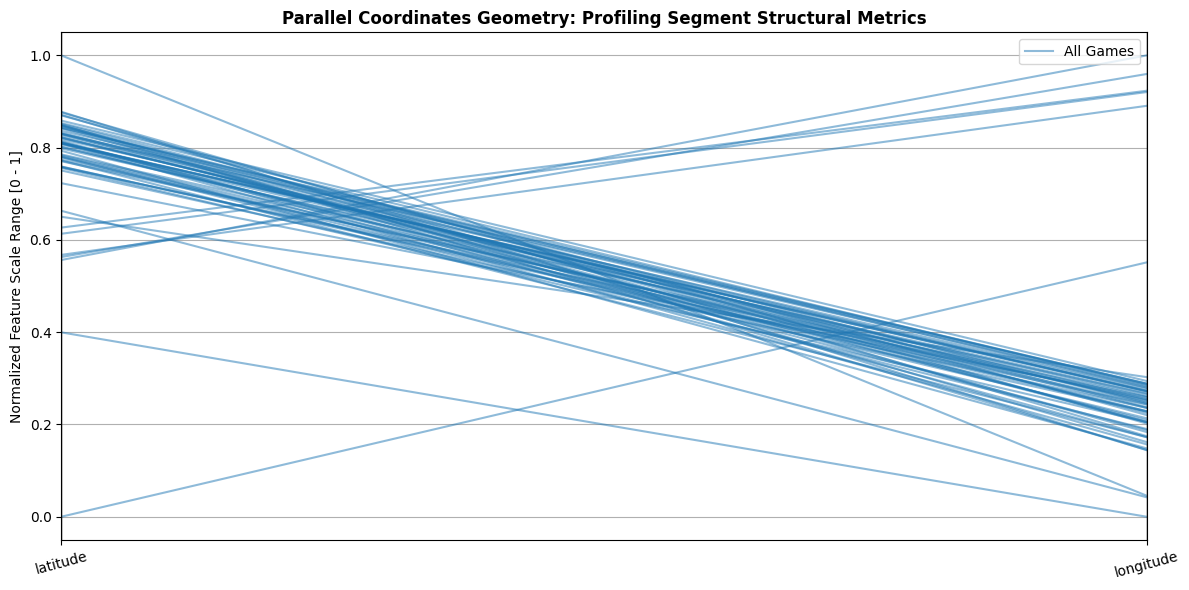

In [31]:
if sales_cols:
    plt.figure(figsize=(12, 6))

    # Dynamically extract up to 4 top unique categories to avoid overlapping lines
    target_genres = list(df_clean[genre_col].value_counts().index[:4])
    df_parallel = df_clean[df_clean[genre_col].isin(target_genres)].copy()

    features_to_plot = score_cols + sales_cols if has_scores else sales_cols

    # Min-Max Normalization scale layer
    df_parallel_norm = df_parallel.copy()
    for col in features_to_plot:
        min_val, max_val = df_parallel[col].min(), df_parallel[col].max()
        if max_val != min_val:
            df_parallel_norm[col] = (df_parallel[col] - min_val) / (max_val - min_val)

    # Render layout profiles using dynamic column handles
    parallel_coordinates(
        df_parallel_norm[[genre_col] + features_to_plot].head(150),
        class_column=genre_col,
        colormap='tab10',
        alpha=0.5
    )

    plt.title('Parallel Coordinates Geometry: Profiling Segment Structural Metrics', fontsize=12, fontweight='bold')
    plt.ylabel('Normalized Feature Scale Range [0 - 1]')
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()
else:
    print("Parallel coordinate mapping requires numerical features.")


### Visualization 11: Andrews Curves

Andrews curves are another way to visualize multivariate data. Each observation is transformed into a curve, and similar observations will have similar curve shapes, often clustering together. We'll use the top few genres for coloring to identify patterns.

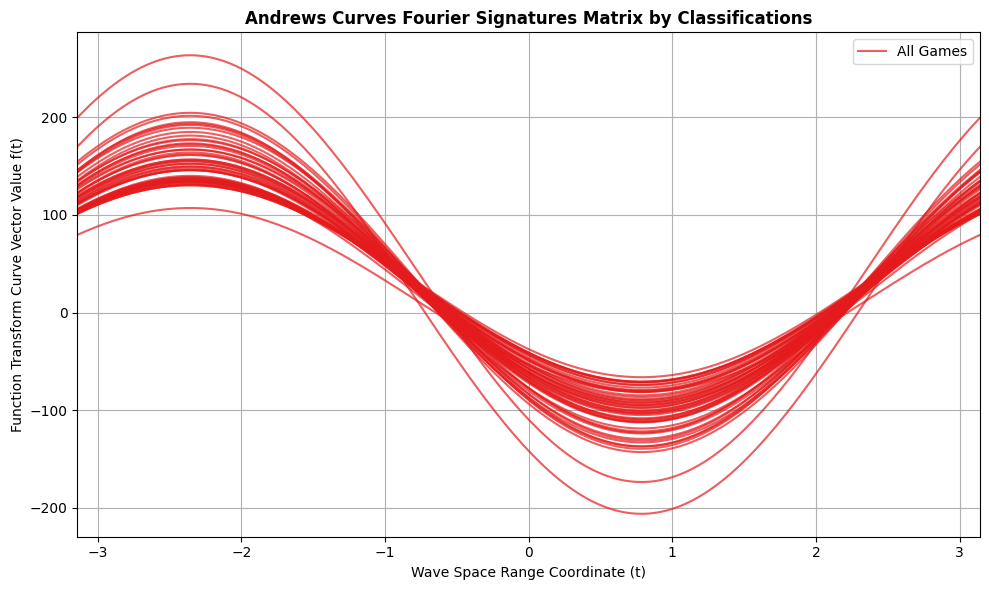

In [32]:
if sales_cols:
    plt.figure(figsize=(10, 6))

    # Keep row snapshot lean so wave patterns are legible
    target_genres = list(df_clean[genre_col].value_counts().index[:4])
    df_andrews = df_clean[df_clean[genre_col].isin(target_genres)].head(50)

    andrews_features = score_cols + [global_col] if (has_scores and global_col) else sales_cols[:3]

    andrews_curves(
        df_andrews[[genre_col] + andrews_features],
        class_column=genre_col,
        colormap='Set1',
        alpha=0.7,
        samples=200
    )

    plt.title('Andrews Curves Fourier Signatures Matrix by Classifications', fontsize=12, fontweight='bold')
    plt.xlabel('Wave Space Range Coordinate (t)')
    plt.ylabel('Function Transform Curve Vector Value f(t)')
    plt.tight_layout()
    plt.show()
else:
    print("Andrews Curves require active numerical data vectors.")
